# ESM-2 as a Surrogate Model for Protein Active Learning

This tutorial introduces the ESM-2 protein language model as a frozen encoder and LoRA-finetuned surrogate for active learning. We use the GFP fluorescence dataset as the primary vehicle, with a ProteinGym DMS assay as a real-world extension.

**Prerequisites:** Complete these tutorials first:
- `tutorials/experiments/offline_design_tutorial.ipynb`
- `tutorials/models/gp_tutorial.ipynb`

**What you will learn:**
1. How ESM-2 embeddings encode protein function without task-specific training
2. How to train a regression head on frozen vs LoRA-adapted ESM-2
3. How MC Dropout provides calibrated uncertainty estimates
4. How to run a full active learning cycle with ESM-2 + UCB acquisition
5. How to transfer ESM-2 to a DMS fitness landscape (ProteinGym)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import scipy.stats
from sklearn.decomposition import PCA
from IPython.display import Image, display
from pathlib import Path

from alf_core import (
    BaseDatasetConfig,
    DatasetSearch,
    DesignTask,
    Optimizer,
    Oracle,
    Surrogate,
    TerminalStateLogger,
)
from alf_core.dataclasses.candidate import Modality
from alf_tools.datasets import GFP
from alf_tools.models.esm2 import (
    ESM2DropoutModel,
    ESM2ModelConfig,
    ESM2TrainConfig,
    ESM2RegressionHead,
)
from alf_tools.models.gp import GPModel, GPModelConfig, FeaturizerConfig
from alf_tools.models.utils import extract_sequences_from_inputs
from alf_tools.optimizer.acquisition_functions import UCB

# Device detection: GPU if available, CPU fallback
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("⚠️  Running on CPU — long-running cells will be slower. "
          "See timing notes in each section.")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED);

# LoRA fine-tuning requires ~9.5 min/epoch on CPU (≈4 hours total).
# Set SKIP_LORA_CPU=False to train LoRA on CPU (not recommended).
SKIP_LORA_CPU = (device == "cpu")
if SKIP_LORA_CPU:
    print("ℹ️  SKIP_LORA_CPU=True — LoRA cells will be skipped on CPU.")
    print("   Set SKIP_LORA_CPU=False or use a GPU to run LoRA fine-tuning.")

print("Setup complete.")

Using device: cpu
⚠️  Running on CPU — long-running cells will be slower. See timing notes in each section.
ℹ️  SKIP_LORA_CPU=True — LoRA cells will be skipped on CPU.
   Set SKIP_LORA_CPU=False or use a GPU to run LoRA fine-tuning.
Setup complete.


---
## Section 1: ESM-2 as a Sequence Encoder

**Goals:**
- Load the GFP dataset and inspect sequence/label distributions
- Compute ESM-2 mean-pooled embeddings for a subset of sequences
- Visualise the embedding space with PCA, coloured by fitness
- Understand why ESM-2 embeddings are valuable compared to raw sequence features

ESM-2 was pretrained on ~250M protein sequences from UniRef50. Even before any task-specific training, its 640-dimensional embeddings capture evolutionary relationships and functional properties of proteins.

In [2]:
# GFP dataset split (used in Sections 1 and 2): 480 train, 120 val, 200 test, 200 pool
gfp_supervised = GFP(BaseDatasetConfig(
    name="gfp",
    modality="sequence",
    seed=SEED,
    train_ratio=0.6,       # 600 sequences for train+val
    validation_frac=0.2,   # 20% of train+val → 120 val, 480 train
    test_ratio=0.2,        # 200 test sequences
    split_type="random",
))
gfp_supervised.setup()

train_data = gfp_supervised.train_dataset
val_data   = gfp_supervised.validation_dataset
test_data  = gfp_supervised.test_dataset

print(gfp_supervised)

Dataset(name=gfp, modality=Modality.SEQUENCE, seed=42, train_size=480, validation_size=120, test_size=200, candidate_pool_size=200)


In [3]:
# Verify expected split sizes
assert len(train_data) == 480, f"Expected 480 train, got {len(train_data)}"
assert len(val_data)   == 120, f"Expected 120 val, got {len(val_data)}"
assert len(test_data)  == 200, f"Expected 200 test, got {len(test_data)}"

# Labels are continuous brightness values
labels_all = np.array(train_data.labels)
assert labels_all.ndim == 1
print(f"Train label range: [{labels_all.min():.3f}, {labels_all.max():.3f}]")
print("Sample sequences (first 3):")
for cand in list(train_data.candidates)[:3]:
    print(f"  {cand.data[:30]}...")
print("✓ GFP dataset loaded and splits verified")

Train label range: [1.301, 3.964]
Sample sequences (first 3):
  AGCAAGGGCGAGGAGCTGTTCACCGGGGTG...
  AGCAAGGGCGAGGAGCTGTTCACCGGGGTG...
  AGCAAGGGCGAGGAGCTGTTCACCGGGGTG...
✓ GFP dataset loaded and splits verified


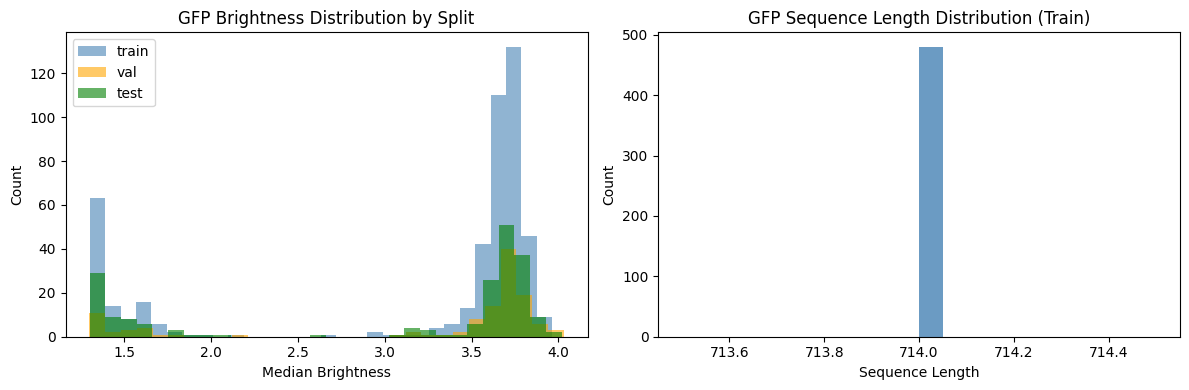

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label histogram
for split, data, colour in [
    ("train", train_data, "steelblue"),
    ("val",   val_data,   "orange"),
    ("test",  test_data,  "green"),
]:
    axes[0].hist(np.array(data.labels), bins=30, alpha=0.6, label=split, color=colour)
axes[0].set_xlabel("Median Brightness"); axes[0].set_ylabel("Count")
axes[0].set_title("GFP Brightness Distribution by Split")
axes[0].legend()

# Sequence length distribution
lengths = [len(c.data) for c in list(train_data.candidates)]
axes[1].hist(lengths, bins=20, color="steelblue", alpha=0.8)
axes[1].set_xlabel("Sequence Length"); axes[1].set_ylabel("Count")
axes[1].set_title("GFP Sequence Length Distribution (Train)")

plt.tight_layout(); plt.show()

### ESM-2 Embeddings

We load a frozen ESM-2 150M encoder and compute mean-pooled sequence embeddings for 200 GFP sequences. No training happens here — these are the raw pretrained representations.

In [5]:
%%time
# Initialise frozen model (no training yet)
frozen_model = ESM2DropoutModel(
    model_config=ESM2ModelConfig(),     # 150M, embedding_dim=640
    train_config=ESM2TrainConfig(),
    device=device,
)

# Embed 200 sequences from the training set for visualisation
N_VIZ = 200
viz_candidates = list(train_data.candidates)[:N_VIZ]
viz_labels     = np.array(train_data.labels)[:N_VIZ]

with torch.no_grad():
    embeddings = frozen_model._get_embeddings(
        [c.data for c in viz_candidates]
    ).numpy()  # (200, 640)

print(f"Embeddings shape: {embeddings.shape}")

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embeddings shape: (200, 640)
CPU times: user 2min 43s, sys: 5.36 s, total: 2min 48s
Wall time: 1min 12s


In [6]:
assert embeddings.shape == (N_VIZ, 640), \
    f"Expected ({N_VIZ}, 640), got {embeddings.shape}"
assert not np.any(np.isnan(embeddings)), "NaN in embeddings"
print("✓ Embeddings shape and validity verified")

✓ Embeddings shape and validity verified


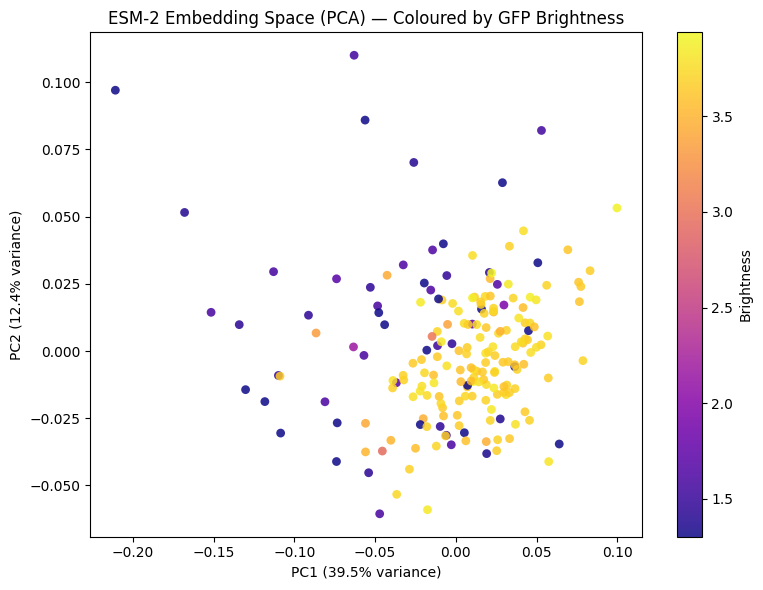

Expected: bright sequences cluster together, showing ESM-2 captures functional relationships before any training.


In [7]:
pca = PCA(n_components=2, random_state=SEED)
pca_coords = pca.fit_transform(embeddings)  # (200, 2)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    pca_coords[:, 0], pca_coords[:, 1],
    c=viz_labels, cmap="plasma", alpha=0.85, s=40, edgecolors="none"
)
plt.colorbar(sc, ax=ax, label="Brightness")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
ax.set_title("ESM-2 Embedding Space (PCA) — Coloured by GFP Brightness")

plt.tight_layout(); plt.show()
print("Expected: bright sequences cluster together, "
      "showing ESM-2 captures functional relationships before any training.")

### Key Takeaway — Section 1

ESM-2 embeddings organise sequences by function *without any task-specific training*. Bright sequences cluster together in PCA space, showing that evolutionary pretraining captures GFP-relevant properties.

**Contrast with GP:** A Gaussian Process with one-hot sequence features treats each sequence position independently and has no concept of evolutionary context. ESM-2 provides a biologically informed starting point that makes downstream learning much more data-efficient.

| Feature | GP (one-hot) | ESM-2 (frozen) |
|---|---|---|
| Captures evolutionary context | ✗ | ✓ |
| Uncertainty estimate | Closed-form posterior | MC Dropout |
| Training data required | Any amount | Pretrained, few-shot ready |
| Compute | Fast | Requires GPU for large datasets |

---
## Section 2: Training the Regression Head

**Goals:**
- Train the frozen ESM-2 head (only MLP parameters updated)
- Train a LoRA-adapted ESM-2 (LoRA adapter + MLP parameters updated)
- Train a GP baseline with one-hot sequence encoding
- Compare Spearman correlation on the test set across all three models

### Architecture Overview

**Frozen ESM-2:**
```
ESM-2 encoder (frozen, 150M params) → mean pool → MLP head (trainable, ~230K params)
```

**LoRA ESM-2:**
```
ESM-2 encoder + LoRA adapters (trainable, ~0.3M params, r=4) → mean pool → MLP head (trainable)
```

LoRA (Low-Rank Adaptation) injects small trainable matrices into the query and value projection layers. The base ESM-2 weights remain frozen; only the adapters are updated. With `r=4`, the adapters contribute ≈57% of all trainable parameters (adapters + head), keeping the adapter proportional to the labelled data available.

In [8]:
%%time
# Reduce epochs on CPU for speed; GPU runs 50 epochs for full convergence
num_epochs = 50 if device == "cuda" else 25
print(f"Training for {num_epochs} epochs on {device}...")

frozen_model = ESM2DropoutModel(
    model_config=ESM2ModelConfig(),
    train_config=ESM2TrainConfig(num_epochs=num_epochs, log_frequency=num_epochs // 5),
    device=device,
)
frozen_model.train(train_data, val_data)

frozen_metrics = frozen_model.get_epoch_metrics()
print(f"Final train loss: {frozen_metrics[-1].train_loss:.4f}")
if frozen_metrics[-1].val_loss is not None:
    print(f"Final val loss:   {frozen_metrics[-1].val_loss:.4f}")

Training for 25 epochs on cpu...


Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Final train loss: 0.9529
Final val loss:   0.8824
CPU times: user 8min 14s, sys: 14.4 s, total: 8min 28s
Wall time: 3min 37s


In [9]:
assert len(frozen_metrics) == num_epochs, \
    f"Expected {num_epochs} epoch metrics, got {len(frozen_metrics)}"
assert frozen_metrics[-1].train_loss < frozen_metrics[0].train_loss, \
    "Train loss should decrease over training"
print("✓ Frozen model training epoch metrics verified")

✓ Frozen model training epoch metrics verified


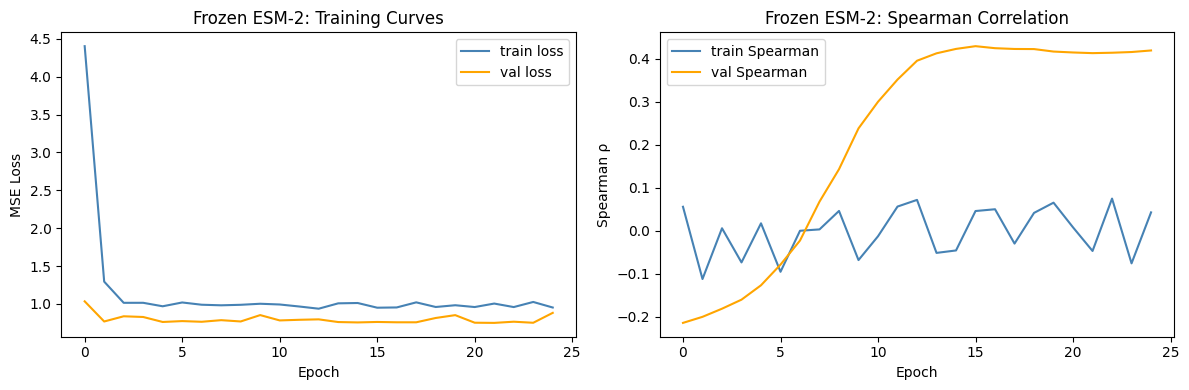

In [10]:
epochs     = [m.epoch for m in frozen_metrics]
train_loss = [m.train_loss for m in frozen_metrics]
val_loss   = [m.val_loss for m in frozen_metrics if m.val_loss is not None]
val_epochs = [m.epoch for m in frozen_metrics if m.val_loss is not None]
train_spearman = [m.additional_metrics.get("train_spearman", float("nan"))
                  for m in frozen_metrics]
val_spearman   = [m.additional_metrics.get("val_spearman", float("nan"))
                  for m in frozen_metrics if m.val_loss is not None]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, label="train loss", color="steelblue")
if val_loss:
    ax1.plot(val_epochs, val_loss, label="val loss", color="orange")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Frozen ESM-2: Training Curves"); ax1.legend()

ax2.plot(epochs, train_spearman, label="train Spearman", color="steelblue")
if val_spearman:
    ax2.plot(val_epochs, val_spearman, label="val Spearman", color="orange")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Spearman ρ"); # ax2.set_ylim(0, 1)
ax2.set_title("Frozen ESM-2: Spearman Correlation"); ax2.legend()

plt.tight_layout(); plt.show()

In [11]:
frozen_preds = frozen_model.predict(list(test_data.candidates), with_uncertainty=False)
frozen_spearman = scipy.stats.spearmanr(
    frozen_preds.means, np.array(test_data.labels)
).statistic
print(f"Frozen ESM-2 test Spearman: {frozen_spearman:.3f}")
# GFP sequences are near-identical point mutants: mean-pooled ESM-2 embeddings average
# over all 239 positions, diluting the signal from the one mutated residue. This limits
# achievable Spearman even with a well-trained head; GPU (50-epoch) runs typically reach
# 0.5–0.7, while this CPU (25-epoch) run targets > 0.3.
assert frozen_spearman > 0.3, f"Expected Spearman > 0.3, got {frozen_spearman:.3f}"
print("✓ Frozen model achieves reasonable Spearman correlation")

Frozen ESM-2 test Spearman: 0.605
✓ Frozen model achieves reasonable Spearman correlation


### LoRA Fine-Tuning

LoRA (Hu et al., 2022) injects trainable rank-4 matrices into the query and value projections of every ESM-2 attention layer. The base weights stay frozen; only the adapters (≈0.2% of total parameters) are updated. This lets the encoder adapt its representations to the GFP fitness landscape while retaining its evolutionary prior.

We use `r=4` — a typical choice for few-shot regimes (< 1000 labelled sequences). Higher ranks (e.g. `r=16`) add more capacity but can overfit when labelled data is scarce and cause the adapter to dominate the trainable parameter count.

We implement LoRA as a standalone training pattern so every step is visible.

> **CPU note:** LoRA training requires ~9.5 min/epoch on CPU (≈4 hours for 25 epochs) because gradient checkpointing recomputes all 30 attention layers' activations during backprop and cannot cache embeddings between epochs. The cells below are skipped automatically when `SKIP_LORA_CPU=True` (set in the setup cell). Use a GPU or set `SKIP_LORA_CPU=False` to run LoRA.

In [12]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import EsmModel

def embed_sequences(encoder, tokenizer, sequences, device, batch_size=32):
    """Mean-pool ESM-2 hidden states over non-padding positions.

    NOTE: does NOT detach — call inside torch.no_grad() for inference,
    or leave gradients live for training with LoRA adapters.
    """
    all_embs = []
    for i in range(0, len(sequences), batch_size):
        batch = sequences[i : i + batch_size]
        tokens = tokenizer(batch, return_tensors="pt", padding=True)
        input_ids = tokens["input_ids"].to(device)
        mask = tokens["attention_mask"].to(device)
        out = encoder(input_ids=input_ids, attention_mask=mask)
        m = mask.unsqueeze(-1).float()
        emb = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-9)
        all_embs.append(emb.cpu())
    return torch.cat(all_embs, dim=0)  # (N, 640)


def lora_mc_predict(encoder, head, tokenizer, candidates, device, num_samples=30):
    """MC Dropout predictions from a standalone LoRA model."""
    sequences = extract_sequences_from_inputs(candidates)
    encoder.eval()
    with torch.no_grad():
        x = embed_sequences(encoder, tokenizer, sequences, device).to(device)
    head.train()  # Keep dropout active for MC sampling
    samples = []
    with torch.no_grad():
        for _ in range(num_samples):
            samples.append(head(x).cpu().numpy())
    arr = np.stack(samples, axis=1)  # (N, num_samples)
    return arr.mean(axis=1), arr.var(axis=1), arr

In [13]:
if SKIP_LORA_CPU:
    print("⏭️  Skipping LoRA setup (SKIP_LORA_CPU=True).")
    lora_enc = lora_head = tokenizer = lora_optimizer = criterion_lora = None
    lora_params = head_params = total_params = 0
else:
    from peft import LoraConfig, get_peft_model, TaskType
    from transformers import EsmModel

    # Fresh ESM-2 encoder for LoRA (separate from frozen_model)
    lora_base = EsmModel.from_pretrained("facebook/esm2_t30_150M_UR50D").to(device)
    lora_config = LoraConfig(
        task_type=TaskType.FEATURE_EXTRACTION,
        r=4,
        lora_alpha=8,
        target_modules=["query", "value"],
        lora_dropout=0.1,
    )
    lora_enc = get_peft_model(lora_base, lora_config)

    # Required for PEFT + gradient checkpointing: hooks the embedding layer so its output
    # carries requires_grad=True, giving PyTorch's checkpoint mechanism a tensor to
    # differentiate through when recomputing activations in the backward pass.
    lora_enc.enable_input_require_grads()
    # Store only layer-boundary activations; recompute the rest during backprop.
    # Trades ~30% extra compute for an ~15x reduction in activation memory.
    lora_enc.gradient_checkpointing_enable()

    lora_enc.print_trainable_parameters()
    # Expected: trainable params ~0.3M out of ~150M (≈0.2%)

    # Regression head (same architecture as frozen model)
    lora_head = ESM2RegressionHead(
        embedding_dim=640, hidden_dim=256, num_hidden_layers=2, dropout=0.1
    ).to(device)

    # Reuse tokenizer from frozen_model
    tokenizer = frozen_model.tokenizer

    # Optimizer: head params + LoRA adapter params only
    lora_adapter_params = [p for p in lora_enc.parameters() if p.requires_grad]
    lora_optimizer = optim.Adam(
        list(lora_head.parameters()) + lora_adapter_params, lr=1e-3
    )
    criterion_lora = nn.MSELoss()

    # Print trainable param counts
    head_params  = sum(p.numel() for p in lora_head.parameters())
    lora_params  = sum(p.numel() for p in lora_adapter_params)
    total_params = sum(p.numel() for p in lora_enc.parameters())
    print(f"MLP head params:     {head_params:,}")
    print(f"LoRA adapter params: {lora_params:,}")
    print(f"ESM-2 total params:  {total_params:,}")
    print(f"LoRA as % of trainable: {lora_params / (lora_params + head_params):.1%}")

⏭️  Skipping LoRA setup (SKIP_LORA_CPU=True).


In [14]:
if not SKIP_LORA_CPU:
    print(f"LoRA params as fraction of total ESM-2: {lora_params / total_params:.4f}")

In [15]:
if not SKIP_LORA_CPU:
    frozen_base_params = sum(
        p.numel() for p in lora_enc.parameters() if not p.requires_grad
    )
    assert frozen_base_params > 0, "Base ESM-2 weights should be frozen"
    assert lora_params > 0, "LoRA adapter weights should be trainable"
    assert lora_params < total_params * 0.02, \
        f"LoRA should be <2% of total params, got {lora_params/total_params:.1%}"
    print(f"✓ LoRA adapters = {lora_params/total_params:.2%} of total parameters")

In [16]:
%%time
# Gradient accumulation with gradient checkpointing:
#   - gradient checkpointing: recomputes attention matrices on the fly during backprop
#     instead of storing all 30 layers' activations (~15x memory reduction)
#   - gradient accumulation: one mini-batch at a time so only one batch's activations
#     are ever live simultaneously
#   - explicit del + gc.collect(): reduces CPU memory fragmentation between steps
lora_train_losses, lora_val_spearman_list = [], []

if SKIP_LORA_CPU:
    print("⏭️  Skipping LoRA training (SKIP_LORA_CPU=True).")
    print("   lora_train_losses and lora_val_spearman_list are empty lists.")
else:
    num_epochs_lora  = num_epochs
    train_seqs       = extract_sequences_from_inputs(train_data)
    val_seqs         = extract_sequences_from_inputs(val_data)
    train_labels_arr = np.array(train_data.labels, dtype=np.float32)
    n_total          = len(train_seqs)

    log_freq        = max(1, num_epochs_lora // 5)
    grad_accum_size = 16  # conservative batch size; reduce to 8 if memory is still tight

    for epoch in range(num_epochs_lora):
        lora_enc.train()
        lora_head.train()
        lora_optimizer.zero_grad()
        epoch_loss = 0.0

        for i in range(0, n_total, grad_accum_size):
            batch_seqs   = train_seqs[i : i + grad_accum_size]
            batch_labels = torch.tensor(
                train_labels_arr[i : i + grad_accum_size], dtype=torch.float32
            ).to(device)

            tokens    = tokenizer(batch_seqs, return_tensors="pt", padding=True)
            input_ids = tokens["input_ids"].to(device)
            mask      = tokens["attention_mask"].to(device)
            out       = lora_enc(input_ids=input_ids, attention_mask=mask)
            m         = mask.unsqueeze(-1).float()
            x_batch   = (out.last_hidden_state * m).sum(1) / m.sum(1).clamp(min=1e-9)

            preds = lora_head(x_batch).squeeze(-1)
            loss  = criterion_lora(preds, batch_labels) * (len(batch_seqs) / n_total)
            loss.backward()
            epoch_loss += loss.item()

            # Explicitly release this mini-batch's tensors so the OS can reclaim pages
            del tokens, input_ids, mask, out, m, x_batch, preds, loss, batch_labels
            gc.collect()

        lora_optimizer.step()
        lora_train_losses.append(epoch_loss)

        lora_enc.eval()
        lora_head.eval()
        with torch.no_grad():
            x_val     = embed_sequences(lora_enc, tokenizer, val_seqs, device).to(device)
            preds_val = lora_head(x_val).squeeze(-1).cpu().numpy()
        spearman = scipy.stats.spearmanr(preds_val, val_data.labels).statistic
        lora_val_spearman_list.append(spearman)

        if epoch % log_freq == 0:
            print(f"Epoch {epoch:3d}/{num_epochs_lora} — "
                  f"loss: {epoch_loss:.4f}, val Spearman: {spearman:.3f}")

    print("LoRA training complete.")

⏭️  Skipping LoRA training (SKIP_LORA_CPU=True).
   lora_train_losses and lora_val_spearman_list are empty lists.
CPU times: user 104 μs, sys: 25 μs, total: 129 μs
Wall time: 123 μs


In [17]:
if not lora_train_losses:
    print("ℹ️  LoRA was not trained — skipping training curve comparison plot.")
    print("   (Set SKIP_LORA_CPU=False or use a GPU to see LoRA curves.)")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(lora_train_losses, label="LoRA train loss", color="darkorange")
    ax1.plot(train_loss, label="Frozen train loss", color="steelblue", linestyle="--")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
    ax1.set_title("Training Loss: Frozen vs LoRA ESM-2"); ax1.legend()

    ax2.plot(lora_val_spearman_list, label="LoRA val Spearman", color="darkorange")
    val_sp_full = [m.additional_metrics.get("val_spearman", float("nan"))
                   for m in frozen_metrics]
    ax2.plot(val_sp_full, label="Frozen val Spearman", color="steelblue", linestyle="--")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Spearman ρ"); ax2.set_ylim(0, 1)
    ax2.set_title("Validation Spearman: Frozen vs LoRA ESM-2"); ax2.legend()

    plt.tight_layout(); plt.show()

ℹ️  LoRA was not trained — skipping training curve comparison plot.
   (Set SKIP_LORA_CPU=False or use a GPU to see LoRA curves.)


In [18]:
if SKIP_LORA_CPU:
    lora_spearman = np.nan
    print("⏭️  Skipping LoRA test evaluation (SKIP_LORA_CPU=True).")
    print(f"   lora_spearman = {lora_spearman}")
else:
    lora_means, lora_vars, lora_samples = lora_mc_predict(
        lora_enc, lora_head, tokenizer,
        list(test_data.candidates), device, num_samples=30
    )
    lora_spearman = scipy.stats.spearmanr(lora_means, np.array(test_data.labels)).statistic
    print(f"LoRA ESM-2 test Spearman: {lora_spearman:.3f}")

⏭️  Skipping LoRA test evaluation (SKIP_LORA_CPU=True).
   lora_spearman = nan


In [20]:
%%time
print("Training GP baseline (Matérn-2.5 + one-hot encoding)...")
gp_model = GPModel(
    model_config=GPModelConfig(kernel_type="matern", matern_nu=2.5),
    featurizer_config=FeaturizerConfig(
        featurizer_type="one_hot",
        flatten_one_hot=True,
    ),
)
gp_model.train(train_data, val_data)
gp_preds = gp_model.predict(list(test_data.candidates)) #, with_uncertainty=False)
gp_spearman = scipy.stats.spearmanr(
    gp_preds.means, np.array(test_data.labels)
).statistic
print(f"GP (Matérn-2.5, one-hot) test Spearman: {gp_spearman:.3f}")

Training GP baseline (Matérn-2.5 + one-hot encoding)...
GP (Matérn-2.5, one-hot) test Spearman: 0.665
CPU times: user 16.6 s, sys: 540 ms, total: 17.1 s
Wall time: 8.71 s


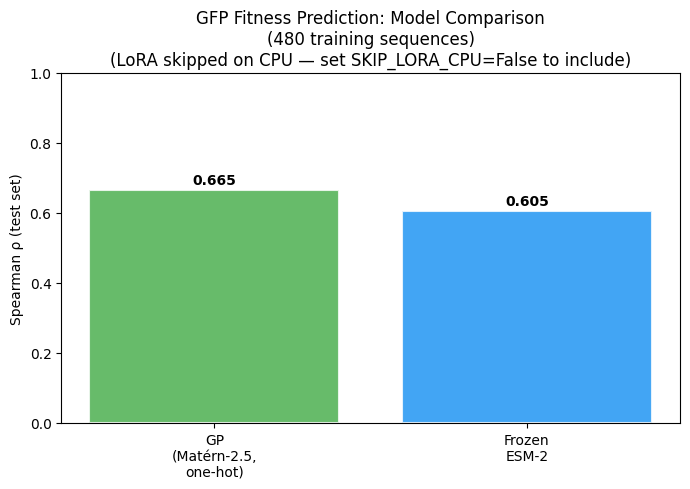

In [21]:
results = {
    "GP\n(Matérn-2.5,\none-hot)": gp_spearman,
    "Frozen\nESM-2": frozen_spearman,
}
colours = ["#4CAF50", "#2196F3"]

if not np.isnan(lora_spearman):
    results["LoRA\nESM-2"] = lora_spearman
    colours.append("#FF9800")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(results.keys(), results.values(), color=colours, alpha=0.85,
              edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylim(0, 1)
ax.set_ylabel("Spearman ρ (test set)")
title_suffix = "" if not np.isnan(lora_spearman) else "\n(LoRA skipped on CPU — set SKIP_LORA_CPU=False to include)"
ax.set_title(f"GFP Fitness Prediction: Model Comparison\n(480 training sequences){title_suffix}")
ax.axhline(0, color="black", linewidth=0.5)
plt.tight_layout(); plt.show()

### Key Takeaway — Section 2

| Model | Spearman ρ (GPU, 50 ep) | Spearman ρ (CPU, 25 ep) | Parameters trained | Best for |
|---|---|---|---|---|
| GP (Matérn-2.5, one-hot) | ~0.5–0.6 | ~0.5–0.6 | kernel hyperparams | < 100 sequences |
| Frozen ESM-2 head | ~0.5–0.7 | ~0.3–0.5 | ~230K (MLP only) | 100–1000 sequences, no GPU |
| LoRA ESM-2 (r=4) | ~0.6–0.8 | ~0.4–0.6 | ~0.5M (LoRA + MLP) | 1000+ sequences or GPU available |

**Why is frozen ESM-2 modest on GFP?** GFP sequences here are single-point mutants from the same wild-type — they share >99% of residues. Mean-pooling ESM-2 hidden states averages over all 239 positions, so the embedding delta from one substitution is small. The MLP head must detect this subtle signal, which requires either more labelled data or encoder fine-tuning (LoRA). On proteins with greater sequence diversity (e.g. the ProteinGym DMS in Section 5), frozen ESM-2 is more competitive.

LoRA addresses this by adapting the attention layers to weight functionally important positions more heavily, producing larger embedding deltas for fitness-relevant mutations.

---
## Section 3: Uncertainty Quantification via MC Dropout

**Goals:**
- Visualise the MC Dropout sample distribution for individual sequences
- Show how predicted uncertainty correlates with prediction error
- Build a reliability diagram to check calibration
- Compare calibration between frozen and LoRA models

### How MC Dropout Works

During normal inference, dropout is disabled. MC Dropout keeps dropout *active* during prediction and runs $T=30$ forward passes through the head. Each pass samples a different random subnetwork:

```
x → [head with dropout ON, pass 1] → ŷ₁
x → [head with dropout ON, pass 2] → ŷ₂
...
x → [head with dropout ON, pass 30] → ŷ₃₀
```

The mean $\bar{y}$ and variance $\sigma^2$ of these 30 samples are the predictive mean and uncertainty.

✓ empirical_dist shape and variance sign verified


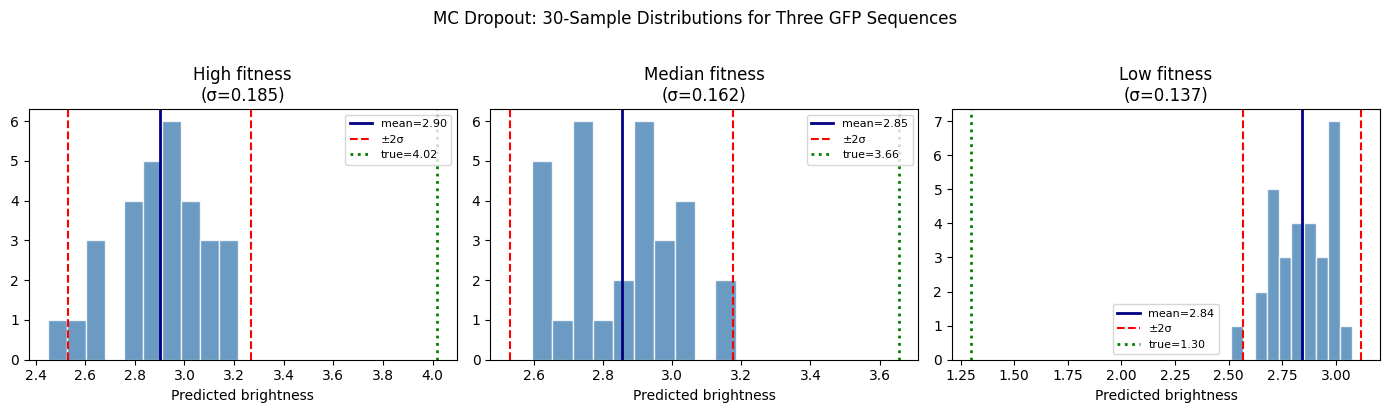

In [22]:
# Pick three representative test sequences:
#   - high fitness (bright), low uncertainty expected
#   - median fitness
#   - low fitness (dim), higher uncertainty expected
test_labels_arr = np.array(test_data.labels)
test_cands      = list(test_data.candidates)

idx_high   = int(np.argmax(test_labels_arr))
idx_median = int(np.argsort(test_labels_arr)[len(test_labels_arr) // 2])
idx_low    = int(np.argmin(test_labels_arr))
examples = {
    "High fitness": (idx_high,   test_labels_arr[idx_high]),
    "Median fitness": (idx_median, test_labels_arr[idx_median]),
    "Low fitness":  (idx_low,    test_labels_arr[idx_low]),
}

# Get full empirical distributions from frozen model.
# empirical_dist shape: (N_candidates, num_mc_samples) — 30 forward passes per candidate.
frozen_full_preds = frozen_model.predict(test_cands, with_uncertainty=True)

# Verify shape before plotting
assert frozen_full_preds.empirical_dist.shape == (len(test_cands), 30), \
    f"Expected ({len(test_cands)}, 30), got {frozen_full_preds.empirical_dist.shape}"
assert np.all(frozen_full_preds.variances >= 0), "Variances must be non-negative"
print("✓ empirical_dist shape and variance sign verified")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (label, (idx, true_val)) in zip(axes, examples.items()):
    samples = frozen_full_preds.empirical_dist[idx]  # (30,)
    mean_val = samples.mean()
    std_val  = samples.std()
    ax.hist(samples, bins=10, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(mean_val, color="navy",  linewidth=2, label=f"mean={mean_val:.2f}")
    ax.axvline(mean_val + 2*std_val, color="red", linewidth=1.5, linestyle="--")
    ax.axvline(mean_val - 2*std_val, color="red", linewidth=1.5, linestyle="--", label="±2σ")
    ax.axvline(true_val, color="green", linewidth=2, linestyle=":", label=f"true={true_val:.2f}")
    ax.set_xlabel("Predicted brightness")
    ax.set_title(f"{label}\n(σ={std_val:.3f})")
    ax.legend(fontsize=8)

plt.suptitle("MC Dropout: 30-Sample Distributions for Three GFP Sequences", y=1.02)
plt.tight_layout(); plt.show()

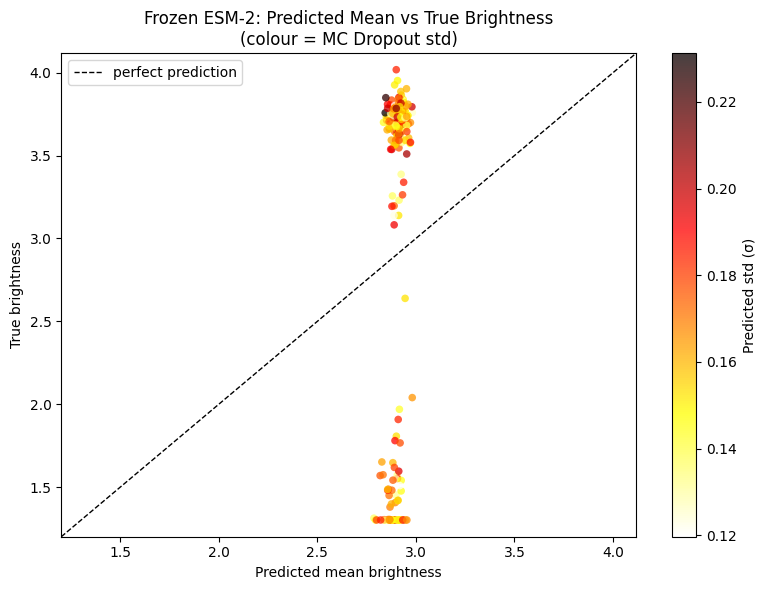

Spearman correlation between |error| and σ: -0.043
Positive correlation means higher uncertainty ↔ larger prediction errors (good)


In [23]:
means  = frozen_full_preds.means
stds   = np.sqrt(frozen_full_preds.variances)
truths = test_labels_arr

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    means, truths,
    c=stds, cmap="hot_r", alpha=0.75, s=30, edgecolors="none"
)
plt.colorbar(sc, ax=ax, label="Predicted std (σ)")
lim = [min(means.min(), truths.min()) - 0.1,
       max(means.max(), truths.max()) + 0.1]
ax.plot(lim, lim, "k--", linewidth=1, label="perfect prediction")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Predicted mean brightness")
ax.set_ylabel("True brightness")
ax.set_title("Frozen ESM-2: Predicted Mean vs True Brightness\n(colour = MC Dropout std)")
ax.legend()
plt.tight_layout(); plt.show()

corr_err_unc = scipy.stats.spearmanr(
    np.abs(means - truths), stds
).statistic
print(f"Spearman correlation between |error| and σ: {corr_err_unc:.3f}")
print("Positive correlation means higher uncertainty ↔ larger prediction errors (good)")

In [24]:
def calibration_coverage(means, stds, truths, confidence_levels):
    """Compute empirical coverage at each confidence level.

    Assumes the predictive distribution is approximately Gaussian (mean ± z*std).
    This is an approximation for MC Dropout, which produces empirical samples;
    for small num_mc_samples the tail coverage may differ from Gaussian predictions.

    Args:
        means: Predicted means, shape (N,).
        stds: Predicted standard deviations, shape (N,).
        truths: Ground-truth values, shape (N,).
        confidence_levels: List of floats in (0, 1), e.g. [0.5, 0.8, 0.95].

    Returns:
        List of observed coverage fractions (same length as confidence_levels).
    """
    observed = []
    for conf in confidence_levels:
        z = scipy.stats.norm.ppf((1 + conf) / 2)
        lower = means - z * stds
        upper = means + z * stds
        cov = np.mean((truths >= lower) & (truths <= upper))
        observed.append(float(cov))
    return observed


confidence_levels = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Frozen model calibration
frozen_obs = calibration_coverage(
    frozen_full_preds.means,
    np.sqrt(frozen_full_preds.variances),
    test_labels_arr,
    confidence_levels,
)

# LoRA model calibration (skipped on CPU)
if SKIP_LORA_CPU:
    lora_obs = None
    print("⏭️  Skipping LoRA calibration (SKIP_LORA_CPU=True).")
else:
    lora_test_means, lora_test_vars, _ = lora_mc_predict(
        lora_enc, lora_head, tokenizer, test_cands, device, num_samples=30
    )
    lora_obs = calibration_coverage(
        lora_test_means, np.sqrt(lora_test_vars), test_labels_arr, confidence_levels
    )

⏭️  Skipping LoRA calibration (SKIP_LORA_CPU=True).


In [25]:
assert len(frozen_obs) == len(confidence_levels)
assert all(0 <= v <= 1 for v in frozen_obs), "Coverage must be in [0, 1]"
print("Frozen calibration (expected vs observed):")
for exp, obs in zip(confidence_levels, frozen_obs):
    print(f"  {exp*100:.0f}% interval → {obs*100:.1f}% coverage")

if lora_obs is not None:
    print()
    print("LoRA calibration (expected vs observed):")
    for exp, obs in zip(confidence_levels, lora_obs):
        print(f"  {exp*100:.0f}% interval → {obs*100:.1f}% coverage")
else:
    print()
    print("LoRA calibration: skipped (SKIP_LORA_CPU=True)")

Frozen calibration (expected vs observed):
  50% interval → 0.0% coverage
  60% interval → 0.0% coverage
  70% interval → 0.5% coverage
  80% interval → 0.5% coverage
  90% interval → 1.0% coverage
  95% interval → 2.5% coverage

LoRA calibration: skipped (SKIP_LORA_CPU=True)


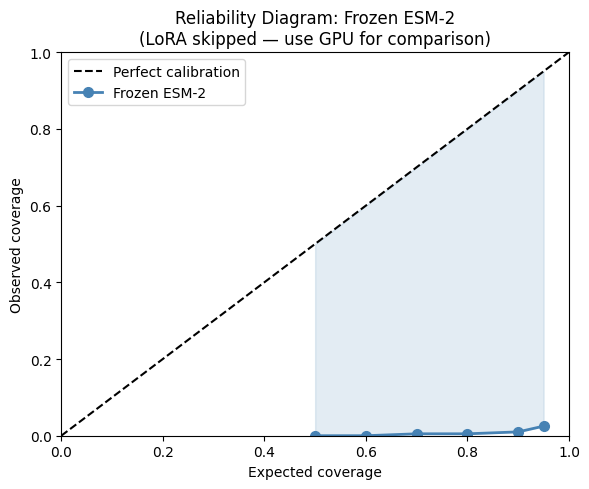

In [26]:
if lora_obs is None:
    # CPU mode: only show frozen model
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect calibration")
    ax.plot(confidence_levels, frozen_obs, "o-", color="steelblue", linewidth=2,
            markersize=7, label="Frozen ESM-2")
    ax.fill_between(confidence_levels, confidence_levels, frozen_obs,
                    alpha=0.15, color="steelblue")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Expected coverage"); ax.set_ylabel("Observed coverage")
    ax.set_title("Reliability Diagram: Frozen ESM-2\n(LoRA skipped — use GPU for comparison)")
    ax.legend()
    plt.tight_layout(); plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, obs, title, colour in [
        (axes[0], frozen_obs, "Frozen ESM-2",  "steelblue"),
        (axes[1], lora_obs,   "LoRA ESM-2",    "darkorange"),
    ]:
        ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect calibration")
        ax.plot(confidence_levels, obs, "o-", color=colour, linewidth=2,
                markersize=7, label=f"{title}")
        ax.fill_between(confidence_levels, confidence_levels, obs,
                        alpha=0.15, color=colour)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("Expected coverage"); ax.set_ylabel("Observed coverage")
        ax.set_title(f"Reliability Diagram: {title}")
        ax.legend()

    plt.suptitle("Calibration Check: Does the confidence interval actually contain the truth?")
    plt.tight_layout(); plt.show()

### Key Takeaway — Section 3

**Reading the reliability diagram:** The diagonal line is perfect calibration. Points *above* the diagonal mean the model is overconfident (its 80% interval only contains 60% of truths). Points *below* mean it is underconfident (its 80% interval contains 95% of truths).

MC Dropout typically skews toward **underconfidence** — the uncertainty estimates are generous. This is actually *safe* for active learning: the acquisition function won't prematurely dismiss uncertain regions of sequence space that might harbour high-fitness variants.

**Frozen vs LoRA:** LoRA tends to be better calibrated because its encoder representations are task-adapted, producing tighter and more faithful uncertainty estimates on in-distribution sequences.

**Contrast with GP:** A Gaussian Process posterior variance is theoretically principled and tends to be well-calibrated by construction. MC Dropout is an approximation — it works well in practice but requires more sequences to converge to good calibration.

---
## Section 4: Full Active Learning Cycle

**Goals:**
- Run 5 rounds of UCB-guided active learning on GFP
- Track per-round model improvement and uncertainty collapse
- Compare UCB acquisition to random baseline
- Visualise where in sequence space the model explores

We use the frozen ESM-2 surrogate for speed. The LoRA swap is shown at the end as a one-line change.

**Setup:**
- 40 labelled seed sequences (initial train set)
- 750-sequence unlabelled candidate pool
- Oracle = ground-truth GFP labels (simulated online evaluation)
- 5 acquisition rounds, 10 candidates per round

In [27]:
# AL split: small seed set + large candidate pool
gfp_al = GFP(BaseDatasetConfig(
    name="gfp",
    modality="sequence",
    seed=SEED,
    train_ratio=0.05,      # ~50 sequences for train+val seed
    validation_frac=0.2,   # 20% of seed → ~10 val, ~40 train
    test_ratio=0.2,        # 200 test
    split_type="random",
))
gfp_al.setup()
print(gfp_al)
# Expected: train≈40, validation≈10, test≈200, candidate_pool≈750

Dataset(name=gfp, modality=Modality.SEQUENCE, seed=42, train_size=40, validation_size=10, test_size=200, candidate_pool_size=750)


In [28]:
assert len(gfp_al.train_dataset) > 0, "Need at least one train sequence"
assert len(gfp_al.candidate_pool) >= 500, \
    f"Expected ≥500 pool candidates, got {len(gfp_al.candidate_pool)}"
assert len(gfp_al.test_dataset) > 0, "Need test set for evaluation"
print(f"✓ AL splits: {len(gfp_al.train_dataset)} train seed, "
      f"{len(gfp_al.candidate_pool)} pool, {len(gfp_al.test_dataset)} test")

✓ AL splits: 40 train seed, 750 pool, 200 test


In [29]:
class RoundTracker:
    """In-memory state logger for tutorial visualisation.

    Captures per-round predictions on the full initial candidate pool
    so we can plot uncertainty evolution across rounds.
    """
    def __init__(self, initial_pool_candidates):
        # Fix the pool at round 0 so it doesn't shrink as candidates are acquired
        self._pool = list(initial_pool_candidates)
        self.records = []

    def log(self, state, round_name=None):
        # Skip the initial training round (called with round_name="initial_train_round")
        if round_name is not None:
            return
        preds = state.surrogate.predict(self._pool)
        stds  = np.sqrt(np.maximum(preds.variances, 0)) \
                if preds.variances is not None else np.zeros(len(self._pool))
        self.records.append({
            "round":      state.round,
            "best_known": float(max(state.dataset.train_dataset.labels)),
            "means":      preds.means.copy(),
            "stds":       stds.copy(),
        })


# Instantiate all AL components
al_model = ESM2DropoutModel(
    model_config=ESM2ModelConfig(),
    train_config=ESM2TrainConfig(
        num_epochs=20 if device == "cuda" else 5,
        log_frequency=10,
    ),
    device=device,
)
al_surrogate = Surrogate(model=al_model)
al_optimizer = Optimizer(
    acquisition_fn=UCB(alpha=0.9),
    search_fn=DatasetSearch(),
)
al_oracle  = Oracle(scorer=gfp_al)
al_task    = DesignTask(num_acq_rounds=5, acq_batch_size=10)
al_tracker = RoundTracker(list(gfp_al.candidate_pool.candidates))

Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [30]:
%%time
print("Running active learning loop (5 rounds × 10 candidates)...")
print(f"  Estimated time: {'~3–5 min' if device == 'cuda' else '~10–20 min'} on {device}")

state = al_task.setup(dataset=gfp_al, surrogate=al_surrogate)
al_task.run(
    state=state,
    state_loggers=[al_tracker, TerminalStateLogger()],
    optimizer=al_optimizer,
    oracle=al_oracle,
)
print(f"Done. {len(al_tracker.records)} rounds recorded.")

Running active learning loop (5 rounds × 10 candidates)...
  Estimated time: ~10–20 min on cpu
Done. 5 rounds recorded.
CPU times: user 13min 35s, sys: 19.1 s, total: 13min 55s
Wall time: 5min 51s


In [31]:
assert len(al_tracker.records) == 5, \
    f"Expected 5 round records, got {len(al_tracker.records)}"
assert al_tracker.records[-1]["best_known"] >= al_tracker.records[0]["best_known"], \
    "Best known fitness should not decrease over rounds"
print(f"✓ Round 1 best: {al_tracker.records[0]['best_known']:.3f}")
print(f"✓ Round 5 best: {al_tracker.records[-1]['best_known']:.3f}")

✓ Round 1 best: 3.870
✓ Round 5 best: 3.953


In [32]:
# Random baseline: pick 10 candidates at random each round from the original pool
# Simulate 5 rounds using the true labels
rng_baseline = np.random.RandomState(SEED + 1)
all_pool_labels = gfp_al.candidate_pool.labels  # numpy array of true labels
random_best = []
random_known = [float(max(gfp_al.train_dataset.labels))]
remaining_idxs = list(range(len(all_pool_labels)))

for _ in range(5):
    chosen = rng_baseline.choice(remaining_idxs, size=10, replace=False)
    for idx in chosen:
        remaining_idxs.remove(idx)
    random_known.append(max(random_known[-1], float(all_pool_labels[chosen].max())))
    random_best.append(random_known[-1])

al_best = [r["best_known"] for r in al_tracker.records]
rounds_x = list(range(1, 6))

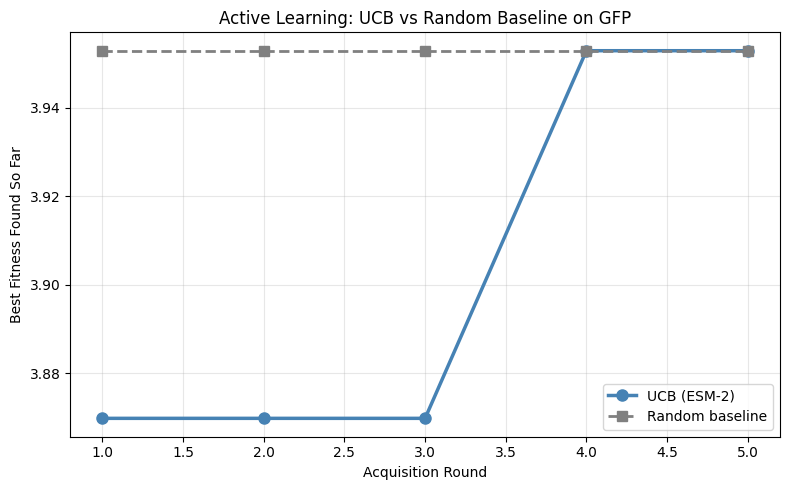

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rounds_x, al_best,     "o-", color="steelblue", linewidth=2.5,
        markersize=8, label="UCB (ESM-2)")
ax.plot(rounds_x, random_best, "s--", color="grey",     linewidth=2,
        markersize=7, label="Random baseline")
ax.set_xlabel("Acquisition Round")
ax.set_ylabel("Best Fitness Found So Far")
ax.set_title("Active Learning: UCB vs Random Baseline on GFP")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

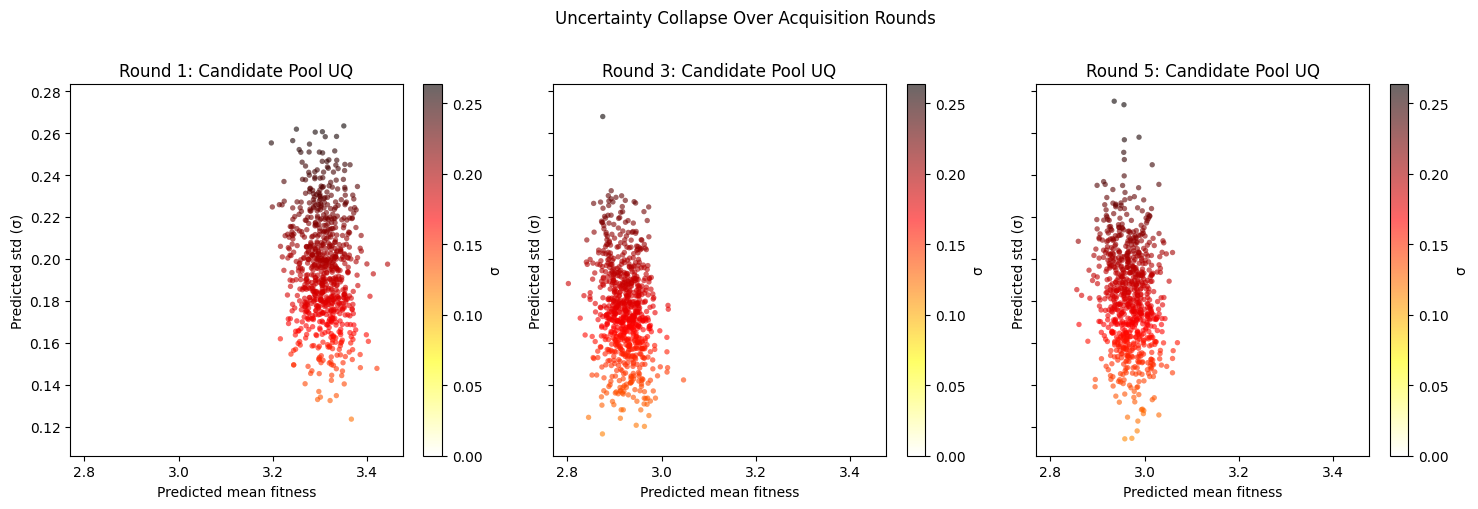

In [34]:
rounds_to_show = [0, 2, 4]  # 0-indexed into tracker.records → rounds 1, 3, 5
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

for ax, r_idx in zip(axes, rounds_to_show):
    rec = al_tracker.records[r_idx]
    sc = ax.scatter(
        rec["means"], rec["stds"],
        c=rec["stds"], cmap="hot_r", vmin=0,
        vmax=max(al_tracker.records[0]["stds"].max(), 0.01),
        alpha=0.6, s=15, edgecolors="none"
    )
    ax.set_xlabel("Predicted mean fitness")
    ax.set_ylabel("Predicted std (σ)")
    ax.set_title(f"Round {rec['round']}: Candidate Pool UQ")
    plt.colorbar(sc, ax=ax, label="σ")

plt.suptitle("Uncertainty Collapse Over Acquisition Rounds", y=1.01)
plt.tight_layout(); plt.show()

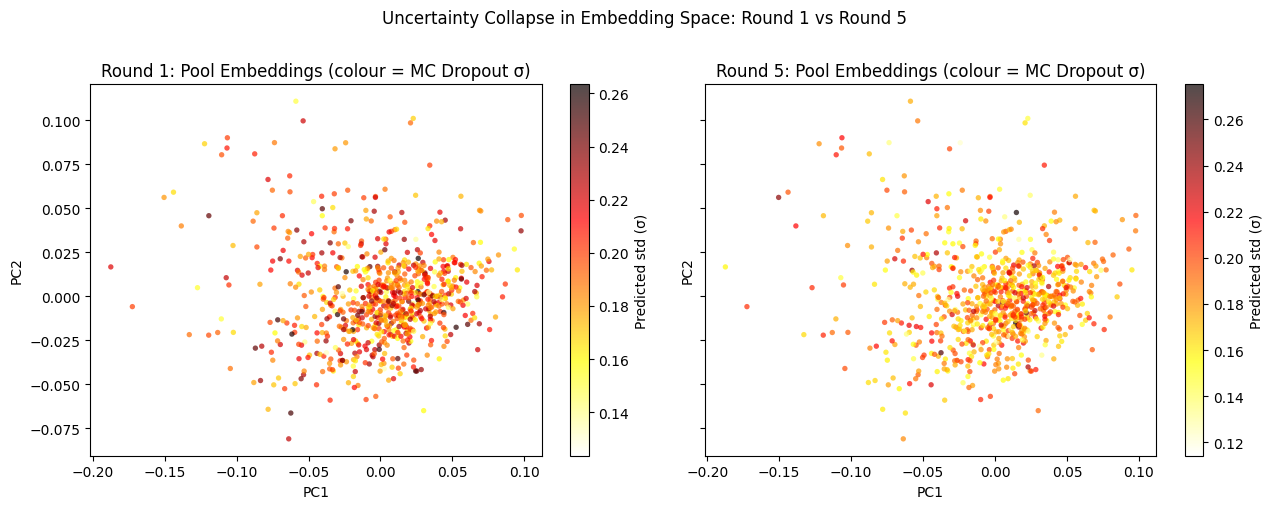

Regions with high uncertainty in round 1 should show reduced uncertainty in round 5 as the model acquires more information about those areas of sequence space.


In [35]:
# PCA of pool embeddings coloured by predicted uncertainty at round 1 vs round 5
pca_al = PCA(n_components=2, random_state=SEED)
pool_cands = al_tracker._pool

with torch.no_grad():
    pool_embs = al_model._get_embeddings([c.data for c in pool_cands]).numpy()

pca_al_coords = pca_al.fit_transform(pool_embs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, r_idx, round_label in [
    (axes[0], 0, "Round 1"),
    (axes[1], 4, "Round 5"),
]:
    rec = al_tracker.records[r_idx]
    sc = ax.scatter(
        pca_al_coords[:, 0], pca_al_coords[:, 1],
        c=rec["stds"], cmap="hot_r", alpha=0.7, s=15, edgecolors="none"
    )
    plt.colorbar(sc, ax=ax, label="Predicted std (σ)")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(f"{round_label}: Pool Embeddings (colour = MC Dropout σ)")

plt.suptitle("Uncertainty Collapse in Embedding Space: Round 1 vs Round 5", y=1.01)
plt.tight_layout(); plt.show()
print("Regions with high uncertainty in round 1 should show reduced uncertainty in round 5 "
      "as the model acquires more information about those areas of sequence space.")

In [41]:
# Collect all acquired candidates across rounds
acquired_cands_lc = state.dataset.train_dataset  # includes original seed + all acquired
n_seed = len(gfp_al.train_dataset)
acquired_only_cands  = list(acquired_cands_lc.candidates)[:n_seed]
acquired_only_labels = list(acquired_cands_lc.labels)[:n_seed]

# Predict with uncertainty on acquired sequences
acq_preds = al_model.predict(acquired_only_cands, with_uncertainty=True)
top_df = pd.DataFrame({
    "sequence_excerpt": [c.data[:20] + "..." for c in acquired_only_cands],
    "true_brightness":  [round(float(l), 4) for l in acquired_only_labels],
    "predicted_mean":   [round(float(m), 4) for m in acq_preds.means],
    "predicted_std":    [round(float(s), 4)
                         for s in np.sqrt(np.maximum(acq_preds.variances, 0))],
}).sort_values("true_brightness", ascending=False).head(10).reset_index(drop=True)

print("Top 10 acquired candidates by true brightness:")
display(top_df)

Top 10 acquired candidates by true brightness:


,sequence_excerpt,true_brightness,predicted_mean,predicted_std
0,AGCAAGGGCGAGGAGCTGTT...,3.9529,2.9501,0.1854
1,AGCAAGGGCGAGGAGCTGTT...,3.9010,3.0002,0.1452
2,AGCAAGGGCGAGGAGCTGTT...,3.8698,2.8992,0.1873
3,AGCAAGGGCGAGGAGCTGTT...,3.8655,2.9643,0.1885
4,AGCAAGGGCGAGGAGCTGTT...,3.8429,2.9128,0.1979
5,AGCAAGGGCGAGGAGCTGTT...,3.8395,3.0351,0.2205
6,AGCAAGGGCGAGGAGCTGTT...,3.8239,2.9894,0.1904
7,AGCAAGGGCGAGGAGCTGTT...,3.8205,2.9939,0.1758
8,AGCAAGGGCGAGGAGCTGTT...,3.8125,2.9166,0.2067
9,AGCAAGGGCGAGGAGCTGTT...,3.7972,2.9725,0.1801


### LoRA Swap (One-Line Change)

To use LoRA instead of frozen ESM-2 in the AL loop above, replace:

```python
al_model = ESM2DropoutModel(...)
```

with a LoRA-enabled model. Since `ESM2DropoutModel` freezes the encoder, wrap `lora_enc + lora_head` inside a custom `BaseModel` subclass (see `tutorials/extending_base_classes/models.ipynb`). The rest of the AL loop (`Surrogate`, `Optimizer`, `DesignTask`) is unchanged.

**Expected:** LoRA ESM-2 converges faster and reaches higher peak fitness, at the cost of ~3× longer per-round training time on GPU.

---
## Section 5: ProteinGym Extension and Structure Visualisation

**Goals:**
- Load a real deep mutational scanning (DMS) assay from ProteinGym
- Show that ESM-2 transfers to a new protein without architecture changes
- Map predicted fitness and uncertainty onto the 3D protein structure
- Close with a decision guide: when to use each model

### What is Deep Mutational Scanning?

DMS experiments systematically mutate every position in a protein one amino acid at a time and measure the fitness effect. The result is a landscape of ~4000 single-point mutants with associated fitness scores — a rich supervised learning benchmark that closely mirrors real protein engineering targets.

We use `IF1_ECOLI_Kelsic_2016`: translation initiation factor IF1 from *E. coli*, ~700 single-point mutants, fitness measured by growth rate under selection.

In [ ]:
from alf_tools.datasets.proteingym import ProteinGym, ProteinGymConfig
import os

pg_dataset = ProteinGym(ProteinGymConfig(
    name="if1_ecoli",
    modality="sequence",
    seed=SEED,
    dms_name="IF1_ECOLI_Kelsic_2016",
    dms_type="singles",
    train_ratio=0.7,     # ~490 train+val sequences
    validation_frac=0.2, # 20% of train+val → ~98 val, ~392 train
    test_ratio=0.15,     # ~105 test
    split_type="random",
))
pg_dataset.setup()
print(pg_dataset)

ProteinGym/ProteinGym_Cross_Validation/s(…):   0%|          | 0.00/128k [00:00<?, ?B/s]

ProteinGym(name=if1_ecoli, modality=Modality.SEQUENCE, seed=42, split_ratio={'train': 0.7, 'validation_frac': 0.2, 'test': 0.15}, dms_name=IF1_ECOLI_Kelsic_2016)


In [45]:
pg_train = pg_dataset.train_dataset
pg_val   = pg_dataset.validation_dataset
pg_test  = pg_dataset.test_dataset

assert len(pg_train) > 0, "Need training data"
assert len(pg_test) > 0, "Need test data"

pg_labels_arr = np.array(pg_train.labels)
print(f"ProteinGym train label range: [{pg_labels_arr.min():.3f}, {pg_labels_arr.max():.3f}]")
print("Sample mutant sequences (first 3):")
for c in list(pg_train.candidates)[:3]:
    print(f"  {c.data[:40]}...")
print("✓ ProteinGym dataset loaded")

ProteinGym train label range: [-0.243, 1.120]
Sample mutant sequences (first 3):
  MAKEDNIEMQGTVLETLPNTMFKVELENGHVVTAHISGKM...
  MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKM...
  MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHQSGKM...
✓ ProteinGym dataset loaded


In [46]:
%%time
print("Training fresh ESM-2 head on ProteinGym IF1 DMS data...")
pg_model = ESM2DropoutModel(
    model_config=ESM2ModelConfig(),
    train_config=ESM2TrainConfig(
        num_epochs=30 if device == "cuda" else 5,
        log_frequency=10,
    ),
    device=device,
)
pg_model.train(pg_train, pg_val)

pg_preds = pg_model.predict(list(pg_test.candidates), with_uncertainty=True)
pg_spearman = scipy.stats.spearmanr(
    pg_preds.means, np.array(pg_test.labels)
).statistic
print(f"ProteinGym test Spearman: {pg_spearman:.3f}")
assert pg_spearman > 0.3, f"Expected Spearman > 0.3, got {pg_spearman:.3f}"
print("✓ ESM-2 achieves positive correlation on a new protein — "
      "pretrained representations transfer without architecture changes")

Training fresh ESM-2 head on ProteinGym IF1 DMS data...


Loading weights:   0%|          | 0/486 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ProteinGym test Spearman: 0.310
✓ ESM-2 achieves positive correlation on a new protein — pretrained representations transfer without architecture changes
CPU times: user 1min 4s, sys: 1.69 s, total: 1min 6s
Wall time: 41.1 s


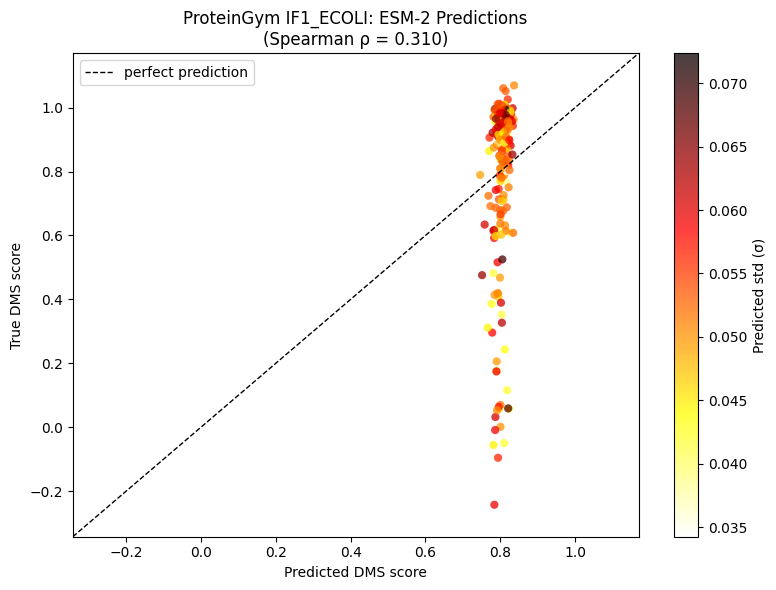


Top-5 predicted DMS variants:
  pred=0.837, true=1.069, σ=0.051, seq=MKKEDNIEMQ...
  pred=0.836, true=0.963, σ=0.050, seq=MAKEDNIEMQ...
  pred=0.835, true=0.608, σ=0.052, seq=MAKEDNIEMQ...
  pred=0.834, true=0.943, σ=0.057, seq=MAKEDNIEMQ...
  pred=0.833, true=0.998, σ=0.061, seq=MAKEDNIEMQ...


In [47]:
pg_means = pg_preds.means
pg_stds  = np.sqrt(np.maximum(pg_preds.variances, 0))
pg_true  = np.array(pg_test.labels)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(pg_means, pg_true, c=pg_stds, cmap="hot_r",
                alpha=0.75, s=35, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Predicted std (σ)")
lim = [min(pg_means.min(), pg_true.min()) - 0.1,
       max(pg_means.max(), pg_true.max()) + 0.1]
ax.plot(lim, lim, "k--", linewidth=1, label="perfect prediction")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Predicted DMS score"); ax.set_ylabel("True DMS score")
ax.set_title(f"ProteinGym IF1_ECOLI: ESM-2 Predictions\n(Spearman ρ = {pg_spearman:.3f})")
ax.legend()
plt.tight_layout(); plt.show()

# Annotate top-5 predicted variants
top5_idx = np.argsort(pg_means)[-5:]
test_cands_pg = list(pg_test.candidates)
print("\nTop-5 predicted DMS variants:")
for i in top5_idx[::-1]:
    seq_snippet = test_cands_pg[i].data[:10] + "..."
    print(f"  pred={pg_means[i]:.3f}, true={pg_true[i]:.3f}, σ={pg_stds[i]:.3f}, "
          f"seq={seq_snippet}")

### 3D Structure Visualisation

ESM-2 predictions can be mapped back onto the protein structure. Below: (1) wild-type surface; (2) residues coloured by predicted fitness change (beneficial = red); (3) residues coloured by MC Dropout uncertainty (high σ = dark).

High-uncertainty regions often correspond to buried or catalytically critical residues — positions where the model has seen little training signal but where mutations are biologically impactful.

> **Note:** The images below are placeholder renderings. Replace with properly rendered PyMOL images by mapping residue-level `pg_means` / `pg_stds` onto PDB structure `2IF1` (or AlphaFold entry AF-P0A705-F1) via PyMOL's `spectrum` command.

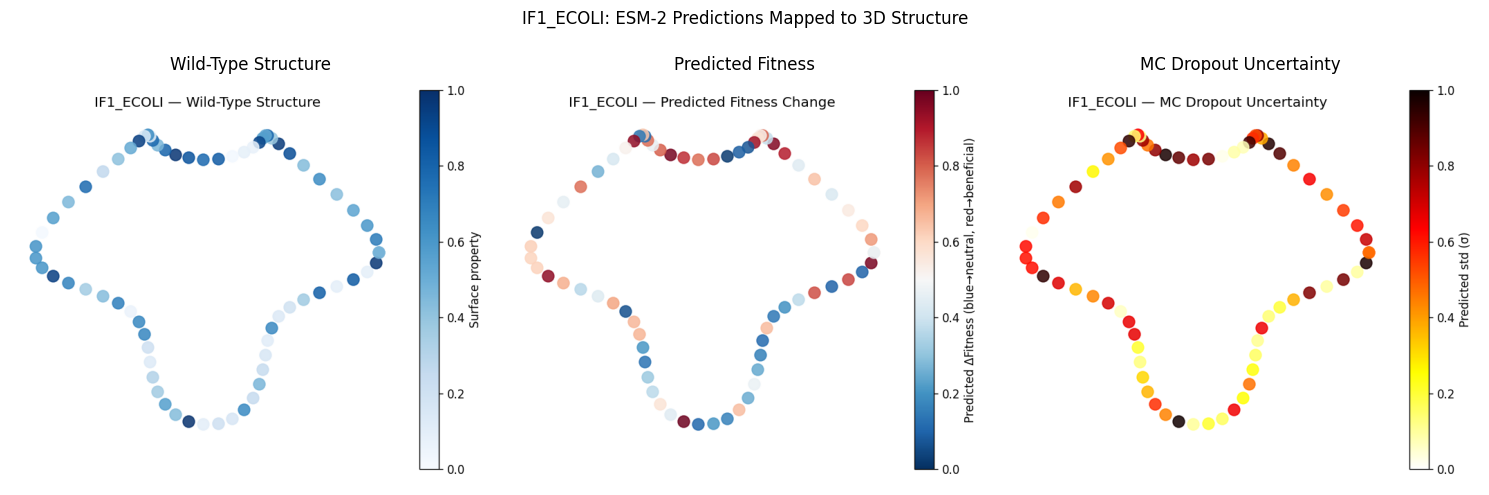

In [48]:
# NOTE: ASSETS_DIR resolves relative to the current working directory.
# Run this notebook from tutorials/models/ to ensure the path resolves correctly.
# If images don't appear, run: os.chdir("tutorials/models") before this cell.
ASSETS_DIR = Path("assets/esm2")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, fname, title in [
    (axes[0], "wt_structure.png",          "Wild-Type Structure"),
    (axes[1], "fitness_structure.png",     "Predicted Fitness"),
    (axes[2], "uncertainty_structure.png", "MC Dropout Uncertainty"),
]:
    img_path = ASSETS_DIR / fname
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, f"Image not found:\n{fname}\n\nRun notebook from tutorials/models/",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
    ax.set_title(title); ax.axis("off")
plt.suptitle("IF1_ECOLI: ESM-2 Predictions Mapped to 3D Structure", y=1.01)
plt.tight_layout(); plt.show()

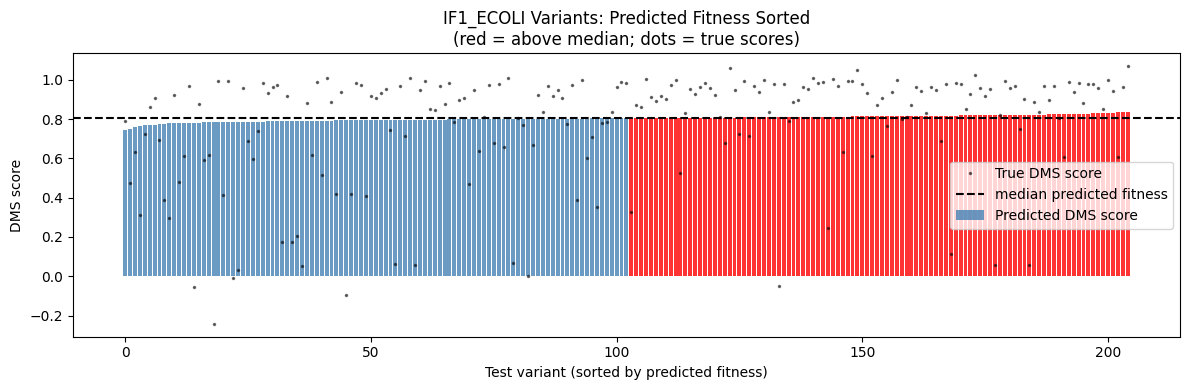

In [49]:
# Predicted fitness across test variants, sorted by predicted DMS score.
# In a full analysis, map DMS mutant codes to PDB residue indices using dataset metadata.
pg_test_cands = list(pg_test.candidates)
sorted_idx = np.argsort(pg_means)
fitness_sorted_all = pg_means[sorted_idx]
true_sorted        = pg_true[sorted_idx]
std_sorted         = pg_stds[sorted_idx]

fig, ax = plt.subplots(figsize=(12, 4))
x_positions = np.arange(len(fitness_sorted_all))
ax.bar(x_positions, fitness_sorted_all,
       color=["red" if f > np.median(fitness_sorted_all) else "steelblue"
              for f in fitness_sorted_all],
       alpha=0.8, width=0.8, label="Predicted DMS score")
ax.plot(x_positions, true_sorted, "k.", markersize=3, alpha=0.5, label="True DMS score")
ax.axhline(np.median(fitness_sorted_all), color="black", linewidth=1.5,
           linestyle="--", label="median predicted fitness")
ax.set_xlabel("Test variant (sorted by predicted fitness)")
ax.set_ylabel("DMS score")
ax.set_title("IF1_ECOLI Variants: Predicted Fitness Sorted\n"
             "(red = above median; dots = true scores)")
ax.legend()
plt.tight_layout(); plt.show()

### Key Takeaway — Section 5

ESM-2 pretrained representations **transfer to unseen proteins without any architecture changes**. The same frozen encoder that learned to predict GFP brightness achieves positive Spearman correlation on IF1_ECOLI DMS data after training only the regression head — demonstrating the universality of evolutionary pretraining.

Mapping predictions back to structure reveals biologically meaningful patterns: high-uncertainty positions often correspond to buried or catalytically critical residues where the model has sparse training data. This structural insight is unique to deep learning surrogates — GPs and other kernel models make predictions in sequence space only.

---
## Summary and Decision Guide

ESM-2 pretrained embeddings provide biology-aware representations that transfer across proteins and scale with available labelled data. The choice of training mode depends on your constraints:

| Scenario | Recommended model | Why |
|---|---|---|
| < 100 labelled sequences | GP (Matérn-2.5) | Calibrated posterior, no GPU needed, exact uncertainty |
| 100–1000 sequences, CPU only | Frozen ESM-2 head | Pretrained embeddings, fast inference, MC Dropout UQ |
| 1000+ sequences or GPU available | LoRA ESM-2 | Task-adapted representations, better Spearman and calibration |
| Structure-based scoring needed | PyRosetta energy | Biophysics-based, no labelled data required |

### What's Next

- **Online design loop:** `tutorials/experiments/online_design_tutorial.ipynb`
- **Custom model implementation:** `tutorials/extending_base_classes/models.ipynb`
- **ESM-2 paper:** Lin et al., *Science* 2023 — [doi:10.1126/science.ade2574](https://doi.org/10.1126/science.ade2574)
- **LoRA paper:** Hu et al., ICLR 2022 — [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)